# Sentinel — Full Pipeline Demo
**All 8 governance gates running end-to-end.**

This notebook runs the complete GovernanceOrchestrator and shows results at each gate.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from sentinel.orchestrator import GovernanceOrchestrator
from sentinel.bias_auditor import GroupStats
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print('Sentinel Governance Orchestrator loaded')
print('All 8 modules ready')

Sentinel Governance Orchestrator loaded
All 8 modules ready


## Scenario 1 — Clean LOW-risk Fraud Detector

In [2]:
o1 = GovernanceOrchestrator()
clean_groups = [
    GroupStats('group_a', 1000, 800, 770, 30, 850),
    GroupStats('group_b', 1000, 790, 760, 30, 840),
]
r1 = o1.run_pipeline(
    model_id='fraud-v2', model_name='FraudDetector', version='2.0',
    approved_by='sarah.chen@bank.com',
    training_data_source='transaction-history-2023',
    bias_groups=clean_groups,
    drift_score=12.0, data_quality=8.0, explainability='SHAP',
    controls_implemented=[
        'data_governance','transparency','human_oversight',
        'accuracy_testing','robustness_testing','cybersecurity',
        'audit_logging','conformity_assessment'
    ],
)
print(f'Verdict:      {r1.verdict}')
print(f'Blocked at:   {r1.blocking_gate}')
print(f'Gates run:    {len(r1.gate_results)}')
print(f'Audit hash:   {r1.audit_chain_hash[:32]}...')
print(f'Completed at: {r1.completed_at}')

Verdict:      APPROVED
Blocked at:   None
Gates run:    4
Audit hash:   98ea817fca787fcead3f7090ddacef82...
Completed at: 2026-06-07T20:12:15.560108+00:00


## Gate-by-Gate Results — Scenario 1

In [3]:
rows = []
for g in r1.gate_results:
    result = g['result']
    status = 'PASSED'
    detail = ''
    if g['gate'] == 'bias':
        detail = f"DIR={result['dir']} legal_risk={result['legal_risk']}"
    elif g['gate'] == 'risk':
        detail = f"score={result['score']} tier={result['tier']}"
    elif g['gate'] == 'compliance':
        detail = f"status={result['status']} score={result.get('score_pct',100)}%"
    elif g['gate'] == 'policy':
        detail = f"verdict={result['verdict']} policy={result['policy']}"
    rows.append({'Gate': g['gate'].upper(), 'Status': status, 'Detail': detail})

df_gates = pd.DataFrame(rows)

def color_status(val):
    return 'background-color: #d4edda; color: #155724' if val == 'PASSED' else 'background-color: #f8d7da'

df_gates.style.applymap(color_status, subset=['Status'])

AttributeError: 'Styler' object has no attribute 'applymap'

## Scenario 2 — Biased Loan AI (should be BLOCKED)

In [4]:
o2 = GovernanceOrchestrator()
biased_groups = [
    GroupStats('White',           5000, 3900, 3700, 200, 4100),
    GroupStats('Black',           2800, 1708, 1560, 148, 1900),
    GroupStats('Hispanic',        2200, 1276, 1150, 126, 1500),
    GroupStats('Asian',           1800, 1476, 1400,  76, 1600),
    GroupStats('Native American',  400,  196,  180,  16,  220),
]
r2 = o2.run_pipeline(
    model_id='loan-v3', model_name='LoanApproval-AI', version='3.0.1',
    approved_by='james.wilson@bank.com',
    training_data_source='FDIC-2005-2023',
    bias_groups=biased_groups,
    drift_score=28.0, data_quality=15.0, explainability='SHAP',
    controls_implemented=['data_governance','human_oversight','cybersecurity','audit_logging'],
)
print(f'Verdict:     {r2.verdict}')
print(f'Blocked at:  {r2.blocking_gate}')
print(f'Reason:      {r2.blocking_reason}')

Verdict:     BLOCKED
Blocked at:  bias
Reason:      DIR=0.598 violates EEOC 4/5ths rule (ECOA)


## Scenario 3 — Hiring AI (medium risk, needs review)

In [5]:
o3 = GovernanceOrchestrator()
hiring_groups = [
    GroupStats('Male_Under40',   3000, 1980, 1900, 80, 2200),
    GroupStats('Female_Over40',  1800,  864,  810, 54, 1100),
]
r3 = o3.run_pipeline(
    model_id='hiring-v1', model_name='HiringScreener', version='1.0',
    approved_by='hr.review@company.com',
    training_data_source='historical-hiring-2020-2023',
    bias_groups=hiring_groups,
    drift_score=22.0, data_quality=18.0, explainability='LIME',
    controls_implemented=[
        'data_governance','transparency','human_oversight',
        'accuracy_testing','audit_logging'
    ],
)
print(f'Verdict:     {r3.verdict}')
print(f'Blocked at:  {r3.blocking_gate}')
print(f'Reason:      {r3.blocking_reason}')

Verdict:     BLOCKED
Blocked at:  bias
Reason:      DIR=0.727 violates EEOC 4/5ths rule (ECOA)


## Pipeline Results Summary Chart

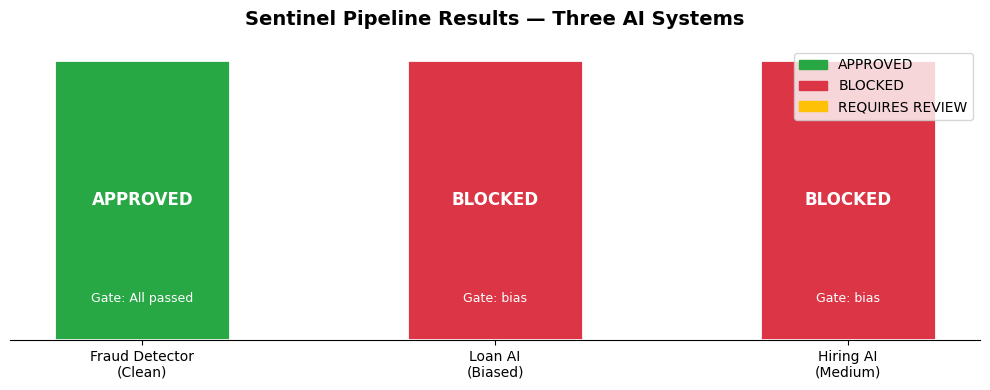

In [6]:
scenarios = [
    {'name': 'Fraud Detector\n(Clean)', 'verdict': r1.verdict, 'gate': r1.blocking_gate or 'All passed'},
    {'name': 'Loan AI\n(Biased)',       'verdict': r2.verdict, 'gate': r2.blocking_gate or 'All passed'},
    {'name': 'Hiring AI\n(Medium)',     'verdict': r3.verdict, 'gate': r3.blocking_gate or 'All passed'},
]

color_map = {'APPROVED': '#28a745', 'BLOCKED': '#dc3545', 'REQUIRES_REVIEW': '#ffc107'}

fig, ax = plt.subplots(figsize=(10, 4))
names    = [s['name']    for s in scenarios]
verdicts = [s['verdict'] for s in scenarios]
colors   = [color_map[v] for v in verdicts]

bars = ax.bar(names, [1, 1, 1], color=colors, edgecolor='white', linewidth=2, width=0.5)
for bar, scenario in zip(bars, scenarios):
    ax.text(bar.get_x() + bar.get_width()/2, 0.5,
            scenario['verdict'], ha='center', va='center',
            fontsize=12, fontweight='bold', color='white')
    ax.text(bar.get_x() + bar.get_width()/2, 0.15,
            f"Gate: {scenario['gate']}", ha='center', va='center',
            fontsize=9, color='white')

ax.set_title('Sentinel Pipeline Results — Three AI Systems', fontsize=14, fontweight='bold', pad=15)
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

legend_patches = [
    mpatches.Patch(color='#28a745', label='APPROVED'),
    mpatches.Patch(color='#dc3545', label='BLOCKED'),
    mpatches.Patch(color='#ffc107', label='REQUIRES REVIEW'),
]
ax.legend(handles=legend_patches, loc='upper right')
plt.tight_layout()
plt.show()

## Audit Trail Integrity Check

In [7]:
for label, o in [('Fraud Detector', o1), ('Loan AI', o2), ('Hiring AI', o3)]:
    verified = o.audit_trail.verify()
    entries  = o.audit_trail.entry_count
    hash_tip = o.audit_trail.terminal_hash[:20]
    status   = 'VERIFIED' if verified else 'TAMPERED'
    print(f'{label:<20} entries={entries:<4} chain={status:<10} hash={hash_tip}...')

Fraud Detector       entries=5    chain=VERIFIED   hash=98ea817fca787fcead3f...
Loan AI              entries=2    chain=VERIFIED   hash=5b59a0b18e1fba1495c4...
Hiring AI            entries=2    chain=VERIFIED   hash=9655a4961c4b7803c54a...
